In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [28]:
# activation functions
def relu(z):
    return np.maximum(0, z)

def relu_back(xbar, z):
    return xbar * (z > 0)

identity = lambda z: z
identity_back = lambda xbar, z: xbar

# initialization
def glorot(nin, nout):
    '''Glorot Xavier initialization'''
    lim = np.sqrt(2 / (nin + nout))
    W = np.random.uniform(-lim, lim, (nin, nout))
    b = np.zeros((1, nout))
    return W, b

# loss function
def mse(yhat, y):
    '''mean squared error loss (MSE)'''
    return np.mean((yhat - y)**2)

def mse_back(yhat, y):
    '''derivative of MSE'''
    return 2 * (yhat - y) / y.size

In [29]:
# layer
class Layer:
    def __init__(self, nin, nout, activation=identity):
        self.W, self.b = glorot(nin, nout)        # initialize weights and biases
        self.activation = activation
        self.activation_back = relu_back if activation == relu else identity_back
        self.cache = {}       # cache for forward/backward pass

    def forward(self, X, train=True):
        '''forward pass'''
        Z = np.dot(X, self.W) + self.b  # Linear transformation
        Xnew = self.activation(Z)       # Apply activation (identity or ReLU)

        if train:
            self.cache['X'] = X
            self.cache['Z'] = Z
        return Xnew
    
    def backward(self, Xnewbar):
        '''backward pass
        Xnewbar = ∂Loss / ∂Xnew - gradient from next layer
        Zbar = ∂Loss / ∂Z - gradient w.r.t pre-activation
        Wbar = ∂Loss / ∂W - gradient w.r.t weights
        bbar = ∂Loss / ∂b - gradient w.r.t bias
        Xbar = ∂Loss / ∂x - graident w.r.t pass backward 

        '''
        Z = self.cache['Z']
        X = self.cache['X']

        # ensure shapes are consistent with forward propagation
        assert Xnewbar.shape == Z.shape, f"Gradient shape mismatch in backward pass. Expected {Z.shape} but got {Xnewbar.shape}."
        Zbar = self.activation_back (Xnewbar, Z)   # shape: (samples, nout)
        Wbar = np.dot(X.T, Zbar)                   # shape: (nin, nout)
        bbar = np.sum(Zbar, axis=0, keepdims=True) # shape: (i1, nout)
        Xbar = np.dot(Zbar, self.W.T)              # shape: (samples, nin)

        self.cache['Wbar'] = Wbar
        self.cache['bbar'] = bbar

        return Xbar

In [30]:
# network
class Network:
    def __init__(self, layers, loss):
        '''initialize network with layers and loss function.'''
        self.layers = layers
        self.loss = loss
        self.loss_back = mse_back if loss == mse else None

    def forward(self, X, y, train=True):
        '''forward pass through all layers'''
        for layer in self.layers:
            X = layer.forward(X, train)
        yhat = X
        L = self.loss(yhat, y)

        # ensure the shapes of yhat and y match
        assert yhat.shape == y.shape, f"Shape mismatch: yhat shape {yhat.shape}, y shape {y.shape}"

        # save cache
        if train:
            self.cache = {'yhat': yhat, 'y': y}
        return L, yhat
    
    def backward(self):
        '''backward pass through all the layers'''
        yhat = self.cache['yhat']
        y = self.cache['y']
        Lbar = self.loss_back(yhat, y)
        for layer in reversed(self.layers):
            Lbar = layer.backward(Lbar)

In [31]:
# optimizer
class GradientDescent:
    def __init__(self, alpha):
        '''initialize optimizer with learning rate alpha'''
        self.alpha = alpha

    def step(self, network):
        '''update weights and biases for all layers'''
        for layer in network.layers:
            layer.W -= self.alpha * layer.cache['Wbar']
            layer.b -= self.alpha * layer.cache['bbar']

Epoch 1, Train Loss: 0.9553, Test Loss: 1.0221
Epoch 101, Train Loss: 0.7759, Test Loss: 0.7903
Epoch 201, Train Loss: 0.5627, Test Loss: 0.5524
Epoch 301, Train Loss: 0.4546, Test Loss: 0.4306
Epoch 401, Train Loss: 0.4066, Test Loss: 0.3767
Epoch 501, Train Loss: 0.3807, Test Loss: 0.3478
Epoch 601, Train Loss: 0.3615, Test Loss: 0.3291
Epoch 701, Train Loss: 0.3441, Test Loss: 0.3125
Epoch 801, Train Loss: 0.3278, Test Loss: 0.3004
Epoch 901, Train Loss: 0.3098, Test Loss: 0.2931
Epoch 1001, Train Loss: 0.2945, Test Loss: 0.2872
Epoch 1101, Train Loss: 0.2813, Test Loss: 0.2797
Epoch 1201, Train Loss: 0.2707, Test Loss: 0.2708
Epoch 1301, Train Loss: 0.2603, Test Loss: 0.2614
Epoch 1401, Train Loss: 0.2485, Test Loss: 0.2508
Epoch 1501, Train Loss: 0.2353, Test Loss: 0.2388
Epoch 1601, Train Loss: 0.2241, Test Loss: 0.2284
Epoch 1701, Train Loss: 0.2145, Test Loss: 0.2201
Epoch 1801, Train Loss: 0.2065, Test Loss: 0.2142
Epoch 1901, Train Loss: 0.2003, Test Loss: 0.2100
MAE = 5.8442

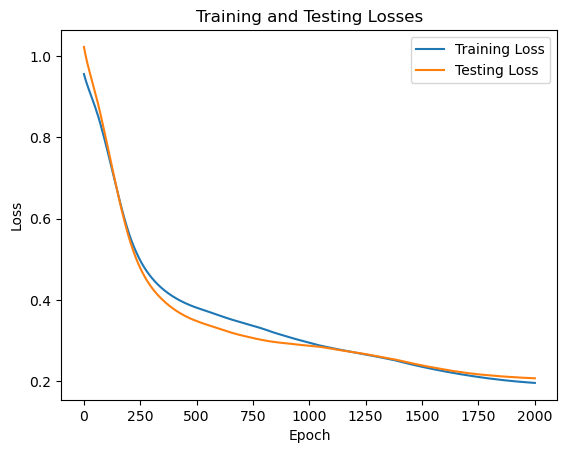

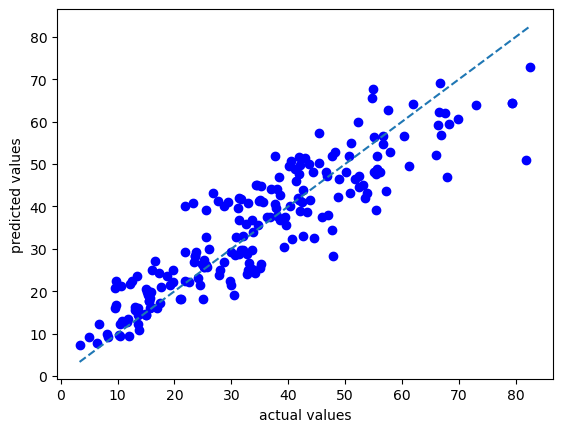

In [32]:
if __name__ == '__main__':

    # ---------- data preparation ----------------
    
    # Read CSV file
    df = pd.read_csv('concrete_data.csv', header=None, skiprows=1)
    
    # drop nan
    df_clean = df.dropna()
    
    # Drop rows with any NaN values
    df_clean = df_clean.dropna()
    
    # Convert to numpy array
    numeric_array = df_clean.values.astype(float)
    
    # Features: ALL columns EXCEPT the last one
    # Label: LAST column
    X = numeric_array[:, :-1]  # All rows, all columns except last
    y = numeric_array[:, -1]   # All rows, only last column
    
    nrows = X.shape[0]
    indices = np.arange(nrows)
    np.random.shuffle(indices)

    X_shuffled = X[indices]
    y_shuffled = y[indices]
    
    split_index = int(0.8 * nrows)

    Xtrain = X_shuffled[:split_index]
    ytrain = y_shuffled[:split_index]
    Xtest = X_shuffled[split_index:]
    ytest = y_shuffled[split_index:]

    # Normalize features
    Xmean = np.mean(Xtrain, axis=0)
    Xstd = np.std(Xtrain, axis=0)
    Xtrain = (Xtrain - Xmean) / Xstd
    Xtest = (Xtest - Xmean) / Xstd
    
    # Normalize labels
    ymean = np.mean(ytrain)
    ystd = np.std(ytrain)
    ytrain = (ytrain - ymean) / ystd
    ytest = (ytest - ymean) / ystd

    # Reshape ytrain and ytest to match network output
    ytrain = np.reshape(ytrain, (len(ytrain), 1))  # Shape: (n_samples, 1)
    ytest = np.reshape(ytest, (len(ytest), 1))    # Shape: (n_samples, 1)

    # First layer input size = number of features (all columns except last)
    input_size = Xtrain.shape[1]
    
    l1 = Layer(input_size, 3, relu)
    #l2 = Layer(32, 16, relu)
    l3 = Layer(3, 1, identity)
    #layers = [l1, l2, l3]
    layers = [l1, l3]
    network = Network(layers, mse)

    alpha = 0.01
    optimizer = GradientDescent(alpha)

    train_losses = []
    test_losses = []
    epochs = 2000

    for i in range(epochs):
        train_loss, _ = network.forward(Xtrain, ytrain, train=True)
        train_losses.append(train_loss)
        network.backward()
        optimizer.step(network)

        test_loss, _ = network.forward(Xtest, ytest, train=False)
        test_losses.append(test_loss)

        if i % 100 == 0:
            print(f'Epoch {i+1}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

    _, yhat = network.forward(Xtest, ytest, train=False)

    # Convert back to original scale
    yhat = (yhat * ystd) + ymean
    ytest = (ytest * ystd) + ymean

    plt.figure()
    plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
    plt.plot(range(1, epochs + 1), test_losses, label='Testing Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Testing Losses')
    plt.legend()

    plt.figure()
    plt.plot(ytest.T, yhat.T, "bo")
    plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], "--")
    plt.xlabel('actual values')
    plt.ylabel('predicted values')
    print("MAE =", np.mean(np.abs(yhat - ytest)))

    plt.show()